# Project 08 -- Anthony Micco

**TA Help:** N/A

**Collaboration:** N/A

**Internet Resources:** N/A

**ChatGPT, Gemini, Claude, etc:** N/A

**Link to AI Chat History**: None

**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

In [34]:
#Practicing with the mixed models example
import statsmodels.formula.api as smf
import pandas as pd
sleep_study_data = pd.read_csv("/anvil/projects/tdm/data/sleepstudy/sleepstudy.csv")

# Fit a mixed-effects model with a random intercept for Subject
mixed_model = smf.mixedlm(
    "Reaction ~ Days",
    sleep_study_data,
    groups=sleep_study_data["Subject"])

mixed_results = mixed_model.fit()

print(mixed_results.summary())

         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Reaction 
No. Observations:  180     Method:             REML     
No. Groups:        18      Scale:              960.4568 
Min. group size:   10      Log-Likelihood:     -893.2325
Max. group size:   10      Converged:          Yes      
Mean group size:   10.0                                 
--------------------------------------------------------
           Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  251.405    9.747 25.794 0.000 232.302 270.508
Days        10.467    0.804 13.015 0.000   8.891  12.044
Group Var 1378.176   17.156                             



## Question 1

In [35]:
#loading in the sleep study data
import pandas as pd

sleep_study_data = pd.read_csv("/anvil/projects/tdm/data/sleepstudy/sleepstudy.csv")

In [36]:
#looking at the data and identifying columns
sleep_study_data.head()

,rownames,Reaction,Days,Subject
0,1,249.5600,0,308
1,2,258.7047,1,308
2,3,250.8006,2,308
3,4,321.4398,3,308
4,5,356.8519,4,308


In [37]:
sleep_study_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  180 non-null    int64  
 1   Reaction  180 non-null    float64
 2   Days      180 non-null    int64  
 3   Subject   180 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 5.8 KB


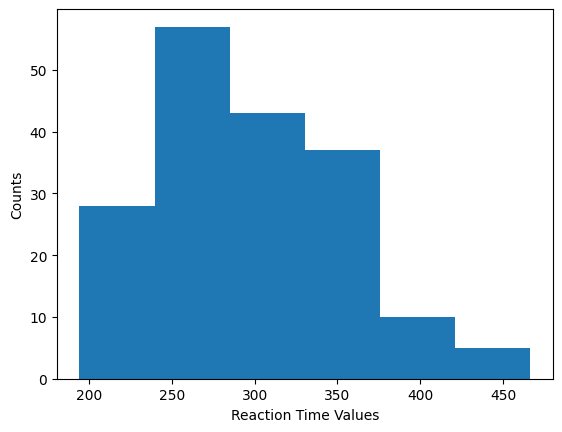

In [38]:
#plotting reaction time
import matplotlib.pyplot as plt

#extracting only the reaction times from the data
reaction_times = sleep_study_data["Reaction"]

plt.figure()
plt.hist(reaction_times, bins=6)
plt.xlabel("Reaction Time Values")
plt.ylabel("Counts")
plt.show()

In [39]:
#determining the max and minimum values for Reaction and Days using df.describe()
sleep_study_data.describe()

,rownames,Reaction,Days,Subject
count,180.000000,180.000000,180.000000,180.000000
mean,90.500000,298.507892,4.500000,341.277778
std,52.105662,56.328757,2.880293,20.320905
min,1.000000,194.332200,0.000000,308.000000
25%,45.750000,255.375825,2.000000,331.000000
50%,90.500000,288.650800,4.500000,336.000000
75%,135.250000,336.752075,7.000000,352.000000
max,180.000000,466.353500,9.000000,372.000000


1b) One thing I notice about the data is that it is right skewed and most of the reaction times fall within the 250-375 ms range. There are not many values larger than 375 ms as the graph shows only about 15-20 values within this range. \
1c) The maximum value for Reaction time is **466.3535** and the minimum value is **194.3322**, while the max value for Days is **9**, and the minimum value is **0**

## Question 2

In [40]:
# determining if there any zero or NA values in the Reaction or Subject variables
sleep_study_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  180 non-null    int64  
 1   Reaction  180 non-null    float64
 2   Days      180 non-null    int64  
 3   Subject   180 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 5.8 KB


In [41]:
(sleep_study_data[["Reaction","Subject"]] == 0).sum()

Reaction    0
Subject     0
dtype: int64

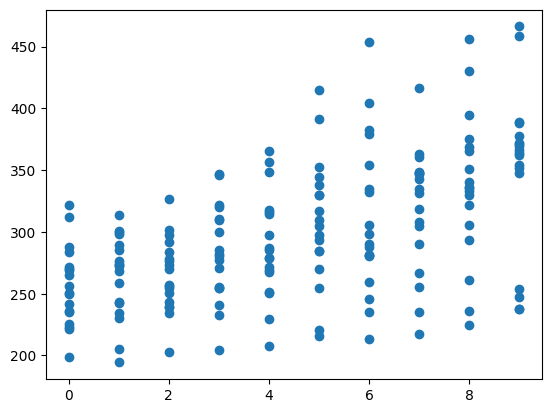

In [42]:
#developing a graph that shows how Days and Reaction Times move together
plt.figure()
plt.scatter(sleep_study_data["Days"], sleep_study_data["Reaction"])
plt.show()

2c) Based on the graph, the relationship between the variables is that as the number of days increases, the reaction time also increases. You can see the minimum value for reaction time appears to increase as the number of days increases, and it is clear the maximum value increases as the days increment as well. 

## Question 3

In [43]:
# fitting a linear regression model with Reaction as response and Days as predictor
import statsmodels.api as sm

X = sleep_study_data["Days"] # For YOU to fill in
y = sleep_study_data["Reaction"] # For YOU to fill in

# Add intercept term
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

In [52]:
#getting the slope and intercept of the model
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Reaction   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     71.46
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           9.89e-15
Time:                        13:21:05   Log-Likelihood:                -950.15
No. Observations:                 180   AIC:                             1904.
Df Residuals:                     178   BIC:                             1911.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        251.4051      6.610     38.033      0.000     238.361     264.449
Days          10.4673      1.238      8.454      0.000       8.024      12.911
==============================================================================
Omnibus:                        1.455   Durbin-Watson:                   0.695
Prob(Omnibus):                  0.483   Jarque-Bera (JB):                1.128
Skew:                           0.015   Prob(JB):                        0.569
Kurtosis:                       3.387   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

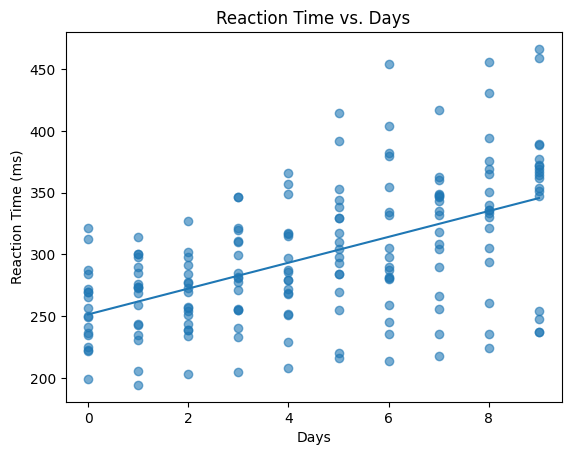

In [57]:
#plotting the regression line to visualize the relationship between Days and Reaction Time

# Create values for regression line (Days on x-axis)
x_vals = np.linspace(
    sleep_study_data["Days"].min(),
    sleep_study_data["Days"].max(),
    100)

# Predicted Reaction values from fitted model
y_vals = model.params["const"] + model.params["Days"] * x_vals

# Plot
plt.figure()
plt.scatter(sleep_study_data["Days"], sleep_study_data["Reaction"], alpha=0.6)
plt.plot(x_vals, y_vals)

plt.xlabel("Days") # For YOU to fill in
plt.ylabel("Reaction Time (ms)") # For YOU to fill in
plt.title("Reaction Time vs. Days") # For YOU to fill in
plt.show()

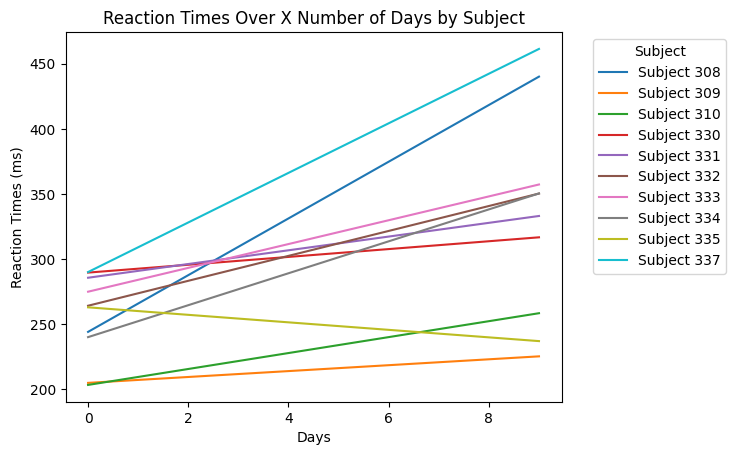

In [56]:
#plotting the 10 unique Subject IDs to examine their variability

plt.figure()
# Select 10 unique subjects
subjects = sleep_study_data["Subject"].unique()[:10]
for subject in subjects:
    subset = sleep_study_data[sleep_study_data["Subject"] == subject]

    # Only fit if enough observations
    if len(subset) > 1:
        m, b = np.polyfit(subset["Days"], subset["Reaction"], 1)

        x_vals = np.linspace(
            subset["Days"].min(),
            subset["Days"].max(),
            100)
        y_vals = m * x_vals + b
        plt.plot(x_vals, y_vals, label=f"Subject {subject}")

plt.xlabel("Days")
plt.ylabel("Reaction Times (ms)")
plt.title("Reaction Times Over X Number of Days by Subject")
plt.legend(title="Subject", bbox_to_anchor=(1.05, 1))
plt.show()

3a) The intercept of the model is 251.4051. The model's slope is 10.4673. \
3b) The single regression line captures the variability across the subjects quite well because it essentially splits the data in half, with half of the reaction times being above the regression line and the other half being below. The influence of the Subject variable is more so a differentiator than an actual impact. Each data point already signifies a Subject in the study, so the data points will be connected by a Subject regression line that encapsulates that specific subject's reaction times over the span of x amount of days. \
3c) One of the main differences I notice in the slopes across the subjects is some subject's reaction time drastically gets slower, so the slope increases as the days increment, while others reaction times gradually improve and the slope slowly decreases over time. This shows the individual variability of the subjects as each subject has their own response to less sleep and can perform better than others on less sleep. This is shown with Subject 308 as they start with a reaction time just under 250 ms on Day 0, and then by Day 10, their reaction time has slowed down to almost 450 ms, whereas Subject 335's reaction time was just about 250 ms on Day 0, and by Day 10, it had improved to about 225 ms.

## Question 4

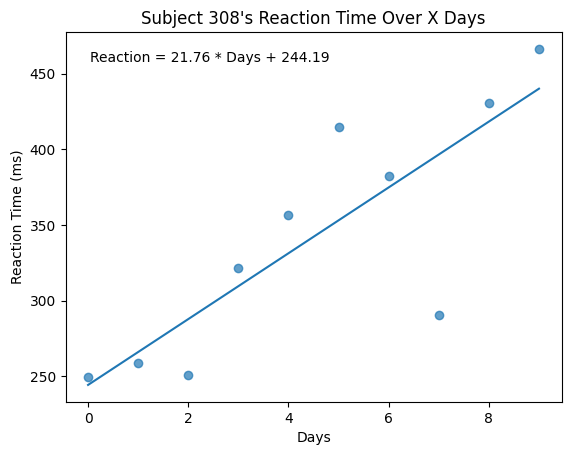

In [58]:
#creating a subset of only Subject 308's observations
subset = sleep_study_data[sleep_study_data["Subject"] == 308]

# Fit simple linear regression (Reaction ~ Days)
m, b = np.polyfit(subset["Days"], subset["Reaction"], 1)

# Create regression line values
x_vals = np.linspace(subset["Days"].min(), subset["Days"].max(), 100)
y_vals = m * x_vals + b

# Plot
plt.figure()
plt.scatter(subset["Days"], subset["Reaction"], alpha=0.7)
plt.plot(x_vals, y_vals)

plt.xlabel("Days")
plt.ylabel("Reaction Time (ms)")
plt.title("Subject 308's Reaction Time Over X Days")

# Add equation text on the plot
eq_text = f"Reaction = {m:.2f} * Days + {b:.2f}"
plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,
    verticalalignment="top")

plt.show()

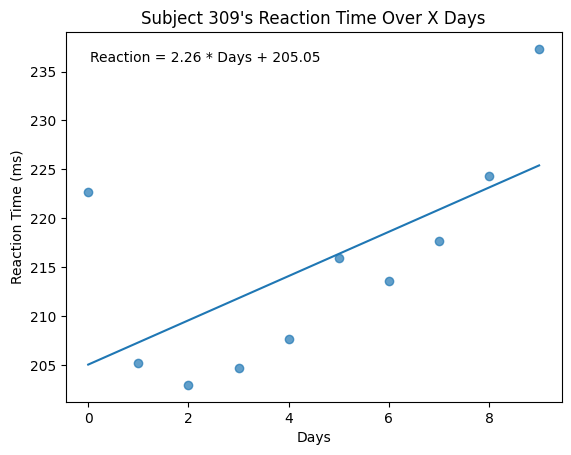

In [59]:
#creating a subset of only Subject 309's observations
subset = sleep_study_data[sleep_study_data["Subject"] == 309]

# Fit simple linear regression (Reaction ~ Days)
m, b = np.polyfit(subset["Days"], subset["Reaction"], 1)

# Create regression line values
x_vals = np.linspace(subset["Days"].min(), subset["Days"].max(), 100)
y_vals = m * x_vals + b

# Plot
plt.figure()
plt.scatter(subset["Days"], subset["Reaction"], alpha=0.7)
plt.plot(x_vals, y_vals)

plt.xlabel("Days")
plt.ylabel("Reaction Time (ms)")
plt.title("Subject 309's Reaction Time Over X Days")

# Add equation text on the plot
eq_text = f"Reaction = {m:.2f} * Days + {b:.2f}"
plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,
    verticalalignment="top")

plt.show()

4c) The main differences between the two equations for each subject is the steepness of their slopes and their y-intercepts. Subject 308's slope of 21.76 is much steeper than subject 309's slope of 2.26, which means that Subject 308's reaction time increases in time much quicker than Subject 309's reaction time. Subject 308's greater y-intercept of 244.19 suggests that their reaction time was already slower than Subject 309 and only got worse as the days increased. The reason for this could be just the invidiual variability between each Subject and their unique response to the lack of sleep. 

## Question 5

In [60]:
#running a mixed-effects models predicting Reaction from Days
import statsmodels.formula.api as smf

# Mixed-effects model with random intercept for Subject
mixed_model = smf.mixedlm(
    "Reaction ~ Days",
    sleep_study_data,
    groups=sleep_study_data["Subject"])

mixed_results = mixed_model.fit()

print(mixed_results.summary())

         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Reaction 
No. Observations:  180     Method:             REML     
No. Groups:        18      Scale:              960.4568 
Min. group size:   10      Log-Likelihood:     -893.2325
Max. group size:   10      Converged:          Yes      
Mean group size:   10.0                                 
--------------------------------------------------------
           Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  251.405    9.747 25.794 0.000 232.302 270.508
Days        10.467    0.804 13.015 0.000   8.891  12.044
Group Var 1378.176   17.156                             



In [61]:
#extracting the subject-specific random intercept effects
random_effects = mixed_results.random_effects
for Subject, effect in random_effects.items():
    print(f"Subject: {Subject}, Random Intercept: {effect.values[0]:.3f}")

Subject: 308, Random Intercept: 40.784
Subject: 309, Random Intercept: -77.850
Subject: 310, Random Intercept: -63.109
Subject: 330, Random Intercept: 4.406
Subject: 331, Random Intercept: 10.216
Subject: 332, Random Intercept: 8.221
Subject: 333, Random Intercept: 16.500
Subject: 334, Random Intercept: -2.997
Subject: 335, Random Intercept: -45.282
Subject: 337, Random Intercept: 72.183
Subject: 349, Random Intercept: -21.196
Subject: 350, Random Intercept: 14.111
Subject: 351, Random Intercept: -7.862
Subject: 352, Random Intercept: 36.378
Subject: 369, Random Intercept: 7.036
Subject: 370, Random Intercept: -6.363
Subject: 371, Random Intercept: -3.294
Subject: 372, Random Intercept: 18.116


5b) The population-level fixed effects are the intercept of 251.405 and slope of 10.467. The subject-specific random intercept effect is the group variance which is 1378.176. The intercept varies acorss subjects as each subject has a different starting reaction time which is indicated by the large variance value. This simply means that different subjects have faster or slower starting reaction times and it sets a baseline for the rest of the observations to be compared to. 
5c) These values represent the difference between the population's intercept and the intercept of each individual Subject's intercept. The positive or negative number signifies if the individual intercept was larger or smaller than the entire population's intercept. These subject-level values are added or subtracted from the population's overall intercept to determine each individual subject's intercept. For example, Subject 308's value of 40.784 is added to the overall intercept of 251.405 to find that the intercept of Subject 308 is approximately 291.405. This indicates that depending on each individual subject, certain people have faster or slower reaction times prior to getting limited sleep. Thus, it sets a baseline for the rest of the study to base each individual's reaction time to.  

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
